<a href="https://colab.research.google.com/github/hyperdbio/Android-inject/blob/master/ex01_%EC%9D%B4%EC%A7%84%EB%B6%84%EB%A5%98_%ED%8F%90%EC%95%94%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%98%88%EC%B8%A1%EC%8B%A0%EA%B2%BD%EB%A7%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
# 환경셋팅
# 2차원 - 머신러닝 해결 가능, 딥러닝 해결 가능
# 딥러닝 학습 흐름, 이진분류 해결하기위한 방법

# cpu - 런타임 유형 유지
# gpu - 계산량을 많이 필요로 할 경우 선택해서 무료 버전 사용 가능(한정된 자원, 하루 8시간 ~ 10시간 사용 가능)

# 드라이브 연동
# 작업 폴더의 경로를 이동
!pwd
# -- 작업폴더(위치) 확인하는 키워드
%cd '/content/drive/MyDrive/Colab Notebooks/클라우드'



/content
/content/drive/MyDrive/Colab Notebooks/클라우드


In [47]:
!pwd
# -- 딥러닝 작업폴더까지 이동 했기 떄문에,주피터와 동일하게 상대경로로 파일 접근이 가능!

/content/drive/MyDrive/Colab Notebooks/클라우드


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 목표
- 폐암환자의 생존을 예측하는 분류 모델을 만들어보자
- 다층퍼셉트론(신경망)을 활용하여 이진 분류 문제를 해결해보자.

### 데이터 불러오기
- header(컬럼) : 데이터를 불러오면서 컬럼명을 설정해주는 키워드
    - None : 인덱스 번호로 컬럼명을 설정하라는 의미
    

In [49]:
data = pd.read_csv('/content/drive/MyDrive/머신러닝/data/ThoraricSurgery.csv')

In [50]:
#전체적인 정보
data.info()

# - 결측치 없음

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 469 entries, 0 to 468
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   293     469 non-null    int64  
 1   1       469 non-null    int64  
 2   3.8     469 non-null    float64
 3   2.8     469 non-null    float64
 4   0       469 non-null    int64  
 5   0.1     469 non-null    int64  
 6   0.2     469 non-null    int64  
 7   0.3     469 non-null    int64  
 8   0.4     469 non-null    int64  
 9   0.5     469 non-null    int64  
 10  12      469 non-null    int64  
 11  0.6     469 non-null    int64  
 12  0.7     469 non-null    int64  
 13  0.8     469 non-null    int64  
 14  1.1     469 non-null    int64  
 15  0.9     469 non-null    int64  
 16  62      469 non-null    int64  
 17  0.10    469 non-null    int64  
dtypes: float64(2), int64(16)
memory usage: 66.1 KB


### 데이터 분리
- 문제와 답 : X, y
- 훈련set와 테스트 set : X_train,X_test,y_train,y_test

In [51]:
# 맨 마지막 컬럼 데이터만 답데이터로 사용
X = data.iloc[:,:17]
# y = data.iloc[:,:17]
y = data.iloc[:,-1]

# 크기확인
print(X.shape, y.shape)

# 신경망에 입력층 연결될 특성의 개수
n_features = X.shape[1]
print('-특성의 개수:', n_features)

(469, 17) (469,)
-특성의 개수: 17


In [52]:
data.head()

,293,1,3.8,2.8,0,0.1,0.2,0.3,0.4,0.5,12,0.6,0.7,0.8,1.1,0.9,62,0.10
0,1,2,2.88,2.16,1,0,0,0,1,1,14,0,0,0,1,0,60,0
1,8,2,3.19,2.50,1,0,0,0,1,0,11,0,0,1,1,0,66,1
2,14,2,3.98,3.06,2,0,0,0,1,1,14,0,0,0,1,0,80,1
3,17,2,2.21,1.88,0,0,1,0,0,0,12,0,0,0,1,0,56,0
4,18,2,2.96,1.67,0,0,0,0,0,0,12,0,0,0,1,0,61,0


In [53]:
from sklearn.model_selection import train_test_split

In [54]:
# 문제, 답
# 7:3
# 랜덤고정값 5
X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size=0.3,
                                                 random_state =5)

# 크기확인
print('train:', X_train.shape, y_train.shape)
print('test:', X_test.shape, y_test.shape)

train: (328, 17) (328,)
test: (141, 17) (141,)


### keras 를 활용하여 딥러닝 신경망 구축 !
- 1. 신경망 구조 설계
- 2. 학습/평가 방법 설정 : compile(컴파일), 컴퓨터가 모델을 이해하도록 번역하는 작업
- 3. 학습 및 학습 결과 시각화
- 4. 모델 예측 및 평가

In [55]:
# 신경망 구조 설계 하기 위한 도구
# -- 뼈대 구축
from tensorflow.keras.models import Sequential

# -- 층 내용 정의
from tensorflow.keras.layers import Dense

In [56]:
# 1. 신경망 구조 설계
model = Sequential() # 뼈대구축

# 입력층 + 중간층1
# input_dim : 입력 데이터의 특성 개수 연결 키워드(n_features=17)
# activation : 역치, 활성화함수 -> 들어온 자극(데이터)에 대한 응답여부(다음 뉴런으로 전달할지)을 결정하는 함수
# ! activation의 종류는 다양함
# model.add(Dense(유닛 개수, 입력 크기 , 활성화함수)
model.add(Dense(units=10, input_dim=n_features , activation='sigmoid'))
# units : 중간층1 뉴런(퍼셉트론)의 개수를 설정하는 키워드
# input_dim : 입력층에서만 사용되는 키워드
# activation : 중간층에 현재 sigmoid가 연결됨 -> 변경될 수 있음(종류 다양함)


# 중간층 2개
# 6
model.add(Dense(units=6, activation='sigmoid'))

# 4
model.add(Dense(units=4, activation='sigmoid'))

# 출력층
# 회귀 : units=1, activation='linear'(생략가능)
# 이진분류(0,1) : units=1, activation='sigmoid'
model.add(Dense(1, activation='sigmoid'))

# 정보요약
model.summary()

# Param : 모델의 복잡도를 나름대로 추정하는 크기 값
# 현재 모델은 총 270 개의 w,b값이 존재함

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 10)             │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 279 (1.09 KB)

 Trainable params: 279 (1.09 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# 2. 학습 / 평가 방법 설정
# -- compile
# loss : 'binary_crossentropy' # 에러 측정
# optimizer : 'sgd' # 최적화함수: 경사하강법(최적의 w,b값을 찾아내는 기술/방법)
# metrics : ['accuracy'] # 모델 성능 평가 지표 : 정확도
model.compile(loss='binary_crossentropy',
              optimizer='sgd', # 경사하강법 - 확률적 경사 하강법 => w,b찾아나가는 방법
              metrics=['accuracy']

              )

# 실제 0 - 1.0, 예측 0 - 0.68 => error: 0.32



In [58]:
model.compile(
    optimizer='sgd',
    loss='binary_crossentropy',  # 원-핫 인코딩이면 categorical
    metrics=['accuracy']
)

In [59]:
# 3. 모델 학습 및 시각화
# 학습 반복 횟수 : epochs
# 학습 결과 저장 : 변수 대입 h
# 학습 문제, 학습 답
h = model.fit(X_train,y_train, epochs=100)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8555 - loss: 0.5601
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8389 - loss: 0.5542  
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8300 - loss: 0.5486
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8548 - loss: 0.5240 
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8752 - loss: 0.5010 
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8662 - loss: 0.4966 
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8402 - loss: 0.5079
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8572 - loss: 0.4877 
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8447 - loss: 0.4921
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8685 - loss: 0.4659
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8584 - loss: 0.4690 
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

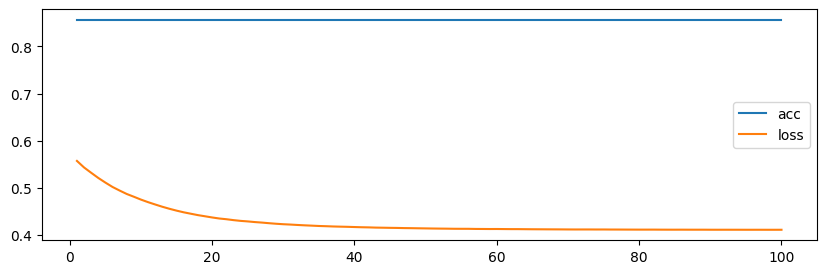

In [63]:
# 학습현황 시각화
# h, history
# 학습 할 때 출력되는 현황의 내용을 담아둔 변수
h.history.keys()
h.history['accuracy']
h.history['loss']
plt.figure(figsize=(10,3))
plt.plot(range(1,101), h.history['accuracy'], label='acc')
plt.plot(range(1,101), h.history['loss'], label='loss')
plt.legend()
plt.show()

# 모든 사람의 그래프가 시작점이 동일하지 않음
# units -> 뉴런 -> 퍼셉트론 -> 선형함수 : y=wx+b
# pc 첫 시작 w,b 값을 랜덤하게 설정

# w,b 값이 처음부터 오차가 적게 나는 값이 었다면 --> 처음부터 정확도 높은 상황 출력
# 반대의 개념 --> 정확도가 낮더라도 딥러닝 모델 반복횟수가 몇번 지나지 않더라도 빠르게 성능 개선이 됨
# 내부적으로 경사하강법 적용이 잘 된 편 !
#** 경사하강법 : 최적의 w,b를 찾아나가는 방법

In [64]:
# 4. 모델 예측 및 평가
model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


array([[0.14872286],
       [0.14937115],
       [0.1487212 ],
       [0.14872013],
       [0.14872046],
       [0.14872013],
       [0.14872012],
       [0.14872013],
       [0.14872018],
       [0.14876072],
       [0.14991221],
       [0.14872012],
       [0.14872013],
       [0.14872012],
       [0.14874125],
       [0.14872028],
       [0.148726  ],
       [0.14872013],
       [0.1487202 ],
       [0.1487719 ],
       [0.1487205 ],
       [0.14872018],
       [0.14872013],
       [0.14872028],
       [0.14872023],
       [0.14872013],
       [0.1487222 ],
       [0.14872625],
       [0.14872013],
       [0.14872903],
       [0.14872037],
       [0.14872013],
       [0.14878188],
       [0.14872013],
       [0.14872013],
       [0.14875013],
       [0.14872013],
       [0.14873283],
       [0.14872013],
       [0.14872026],
       [0.14872013],
       [0.14874549],
       [0.14876242],
       [0.14875242],
       [0.14872012],
       [0.14872454],
       [0.14872104],
       [0.149

In [66]:
# 모두 0이라고 예측함
# 실제 답 데이터랑 비교
model.evaluate(X_test,y_test)[1] #0.84 , 84% 성능

# 16% 만큼은 오류 발생(예측이 틀린 상황)
# X_test 사망0에 대한 데이터가 많이 들어있는 상황 (데이터 편향)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8480 - loss: 0.4263


0.8368794322013855